<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week12_0519_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0519(월) 12주차 과제*\
*딥러닝 파이토치 교과서 5장 합성곱 신경망1 - 02  p.179-200*

# 5.2 합성곱 신경망 맛보기

## fashion_mnist 데이터셋을 사용하여 합성곱 신경망 구현

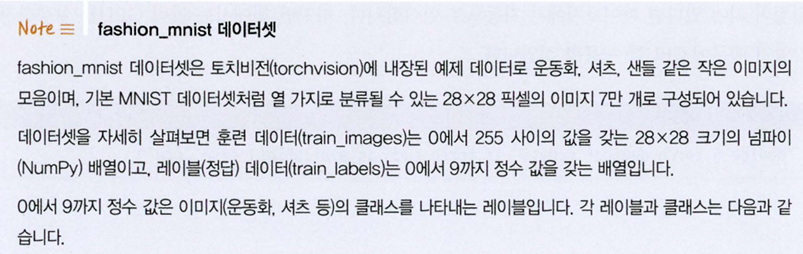

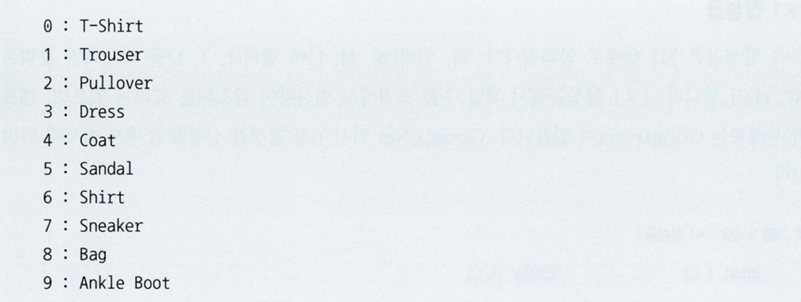

In [2]:
# 라이브러리 호출

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms  # 데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

In [3]:
# CPU 혹은 GPU 장치 확인

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


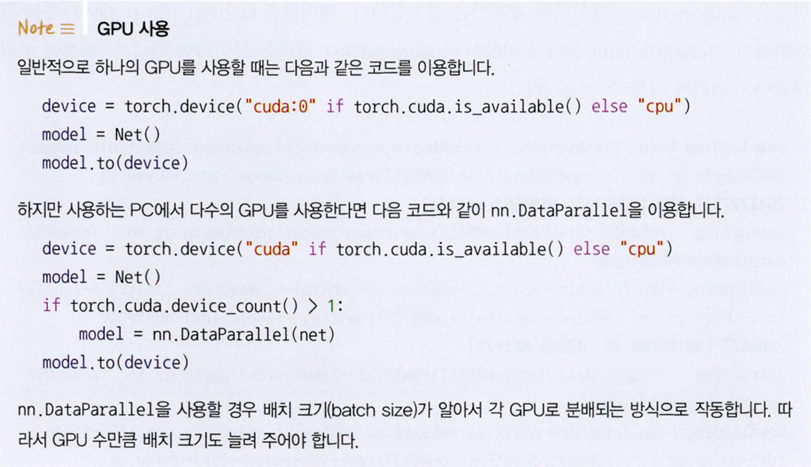

In [4]:
# 토치비전에서 fashion_mnist 데이터셋 내려받기

train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True,
                                                  transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True, train=False,
                                                 transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


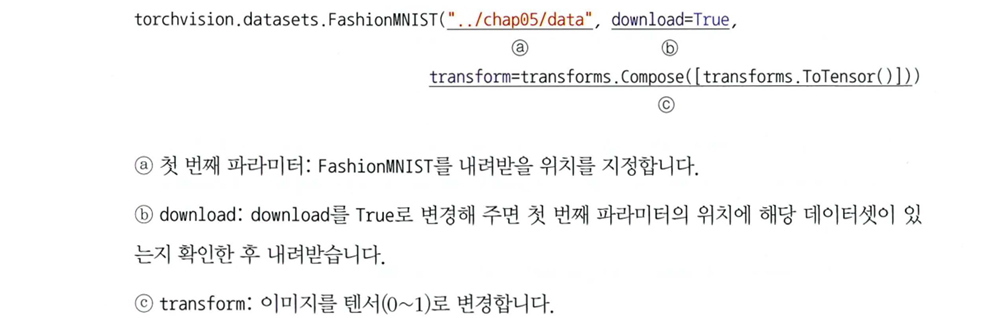

In [5]:
# fashion_mnist 데이터를 데이터로더에 전달

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

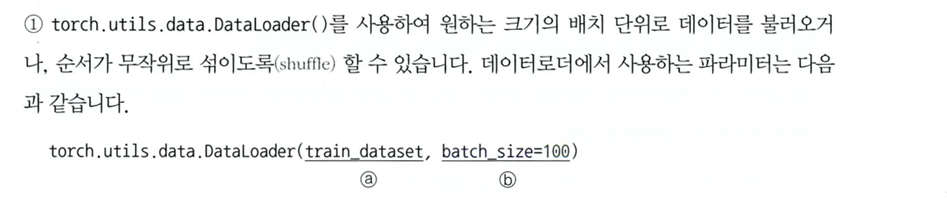

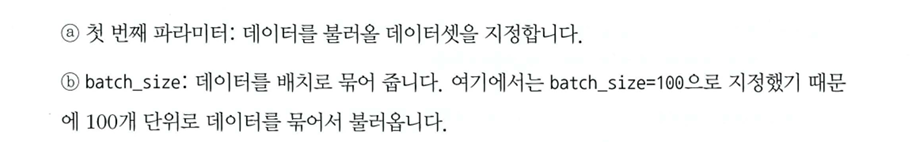

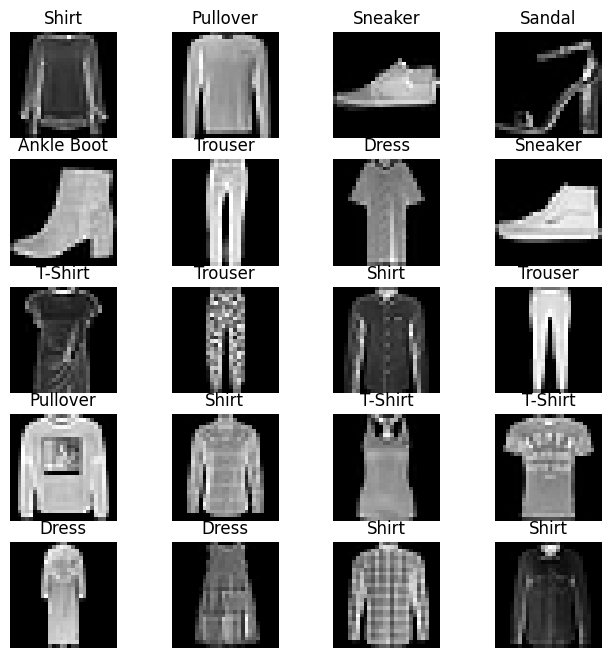

In [6]:
# 분류에 사용될 클래스 정의

labels_map = {0: 'T-Shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
              5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}

fig = plt.figure(figsize=(8,8))     # 출력할 이미지의 가로세로 길이로, 단위는 inch
columns = 4
rows = 5
for i in range(1, columns*rows +1):
    img_xy = np.random.randint(len(train_dataset))
    img = train_dataset[img_xy][0][0,:,:]
    fig.add_subplot(rows, columns, i)
    plt.imshow(img, cmap='gray')
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

- np.random: 무작위로 데이터를 생성할 때 사용
- np.random.randint(): 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용
    - 따라서 random.randint(len(train_dataset)) 의미는 0~(train_dataset의 길이) 값을 갖는 분포에서 랜덤한 숫자 한 개를 생성하라는 의미

```python
#  random.rand & random.randn 예시

import numpy as np
np.random.randint(10)     # 0~10의 임의의 숫자 출력

np.random.randint(1, 10)  # 1~9의 임의의 숫자 출력

np.random.rand(8)         # 0~1 사이의 정규표준분포 난수를 행렬로 (1x8) 출력

np.random.rand(4, 2)      # 0~1 사이의 정규표준분포 난수를 행렬로 (4x2) 출력

np.random.rand(8)         # 평균이 0이고, 표준편차가 1인 가우시안 정규분포 난수를 행렬로 (1x8) 출력

np.random.randn(4, 2)     # 평균이 0이고, 표준편차가 1인 가우시안 정규분포 난수를 행렬로 (4x2) 출력
```

```python
# train_dataset을 이용한 3차원 배열을 생성
# 배열 예시

import numpy as np

examp = np.arange(0, 100, 3)  # 1~99의 숫자에서 3씩 건너뛴 행렬을 생성
examp.resize(6, 4)

examp[3]                      # 3행에 해당하는 모든 값들을 출력(행과 열은 0부터 시작)

examp[3, 3]                   # 3행의 3번째 열에 대한 값을 출력

examp[3][3]                   # 3행의 3번째 열에 대한 값을 출력하기 때문에 바로 앞의 결과와 동일
```

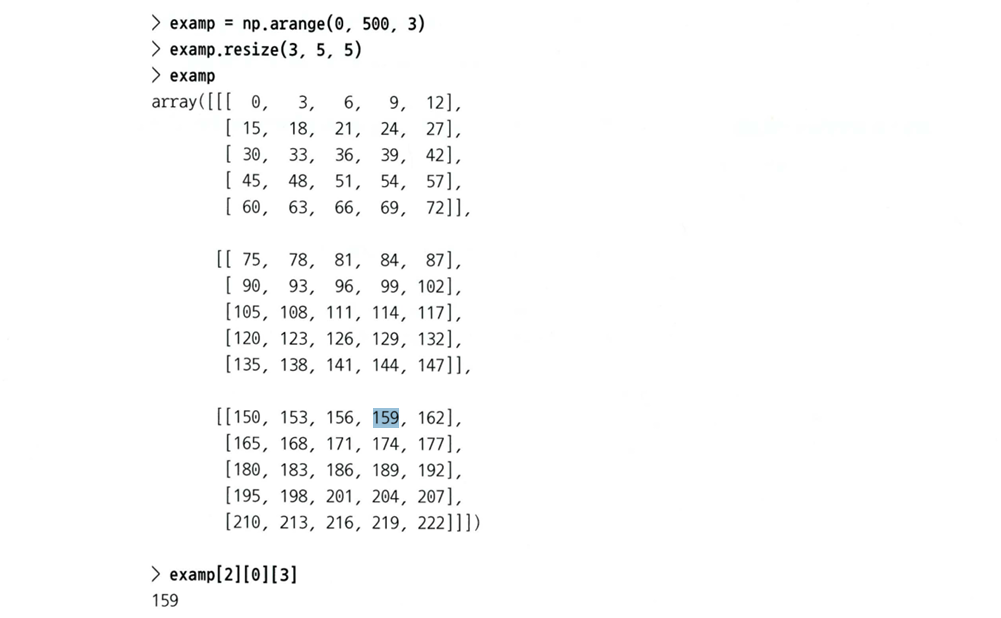

    즉, train_dataset[img_xy][0][0,:,:]는 train_dataset에서 [img_xy][0][0,:,:]에 해당하는 요소 값을 가져오겠다는 의미

> ConvNet이 적용되지 않은 네트워크 생성

In [12]:
# 심충 신경망 모델 생성

class FashionDNN(nn.Module):
    def __init__(self):                                             # (1)
        super(FashionDNN, self).__init__()
        self.fc1 = nn.Linear(in_features=784, out_features=256)     # (2)
        self.drop = nn.Dropout(0.25)                                   # (3)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)

    def forward(self, input_data):                                  # (4)
        out = input_data.view(-1, 784)                              # (5)
        out = F.relu(self.fc1(out))                                 # (6)
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

    # (1)
    클래스(class) 형태의 모델은 항상 torch.nn.Module을 상속받음.
    __init__()은 객체가 갖는 속성 값을 초기화하는 역할을 하며 객체가 생성될 때 자동으로 호출됨.
    super(FashionDNN,self).__init__()은 nn.Module 클래스를 상속받겠다는 의미.

    # (2)
    nn: 딥러닝 모델(네트워크) 구성에 필요한 모듈이 모여 있는 패키지
    Linear: 단순 선형 회귀 모델을 만들 때 사용함.

    실제로 데이터 연산이 진행되는 forward() 부분에는 첫 번째 파라미터 값만 넘겨주게 되며, 두 번째 파라미터에서 정의된 크기가 forward() 연산의 결과가 됨.

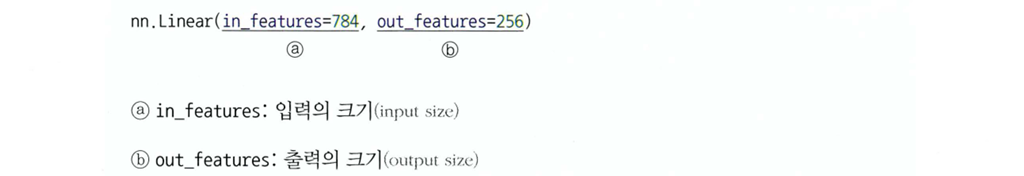

    # (3)
    torch.nn.Dropout(p): p만큼의 비율로 텐서의 값이 0이 되고, 0이 되지 않는 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐.
    예를 들어 p=0.3일 때, 전체 값 중 0.3의 확률로 0이 되며, 0이 되지 않는 0.7에 해당하는 값은 (1/(1-0.7))만큼 커짐.

    # (4)
    forward() 함수: 모델이 학습 데이터를 입력받아서 순전파(forward propagation) 학습을 진행시키며, 반드시 forward라는 이름의 함수여야 함.
    객체를 데이터와 함께 호출하면 자동으로 실행됨.

    순전파 연산: H(x) 식에 입력 x로부터 예측된 y를 얻는 것

    # (5)
    파이토치에서 사용하는 뷰(view): 넘파이의 reshape과 같은 역할로 텐서의 크기(shape)를 변경해 주는 역할을 함.
    따라서 input_data.view(-1 , 784)는 input_data를 (7, 784)의 크기로 변경하라는 의미.
    이때 첫 번째 차원(-1)은 사용자가 잘 모르겠으니 파이토치에 맡기겠다는 의미.

    # (6)
    활성화 함수를 지정할 때는 다음 두 가지 방법이 가능함.
    • F.relu(): forward() 함수에서 정의
    • nn.ReLU(): __init__() 함수에서 정의
    이 둘 간의 차이는 간단히 "사용하는 위치"
    하지만 근본적으로는 nn.functional.xx() / nn.xx()는 사용 방법에 차이가 있음

In [13]:
# nn을 사용하는 예시 코드

import torch
import torch.nn as nn

inputs = torch.randn(64, 3, 244, 244)
conv = nn.Conv2d(in_channels=3, out_channels=64,
                 kernel_size=3, padding=1) # 채널 3개 입력 -> 64개 출력을 위해 3x3크기의 커널 사용
outputs = conv(inputs)
layer = nn.Conv2d(1,1,3)

In [14]:
# nn.functional을 사용하는 예시 코드

import torch.nn.functional as F

inputs = torch.randn(64, 3, 244, 244)
weight = torch.randn(64, 3, 3, 3)
bias = torch.randn(64)
outputs = F.conv2d(inputs, weight, bias, padding=1)

    nn.Conv2d에서 input_channel과 output_channel을 사용해서 연산했다면 functional.conv2d는 입력(input)과 가중치(weight) 자체를 직접 넣어 줌.
    이때 직접 넣어 준다는 의미는 가중치를 전달해야 할 때마다 가중치 값을 새로 정의해야 함을 의미함.
    그 외에 채워야 하는 파라미터들은 nn.Conv2d와 비슷함.

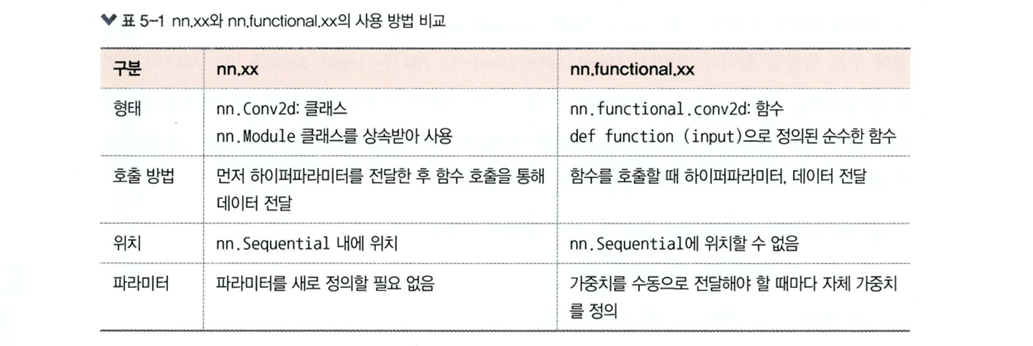

---

## 모델 학습 전에 손실 함수, 학습률, 옵티마이저 정의

In [15]:
# 심층 신경망에서 필요한 파라미터 정의

learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();  # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);   # (1)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


-> 생성한 심층 신경망 모델이 출력됨

    # (1)
    옵티마이저를 위한 경사 하강법은 Adam을 사용하며 학습률을 의미히는 lr은 0.001을 사용한다는 의미

In [17]:
# 심층 신경망을 이용한 모델 학습

num_epochs = 5
count = 0
loss_list = []    # (1)
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:   # (2)
        images, labels = images.to(device), labels.to(device)   # (3)

        train = Variable(images.view(100, 1, 28, 28))   # (4)
        labels = Variable(labels)

        outputs = model(train)   # 학습 데이터를 모델에 적용
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):    # count를 50으로 나누었을 때 나머지가 0이 아니라면 실행
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)

                test = Variable(images.view(100, 1, 28, 28))

                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()

                total += len(labels)

            accuracy = correct * 100 / total   # (5)
            loss_list.append(loss.data)        # (1')
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5647361874580383, Accuracy: 84.18000030517578%
Iteration: 1000, Loss: 0.49370265007019043, Accuracy: 84.80000305175781%
Iteration: 1500, Loss: 0.3664904832839966, Accuracy: 85.33000183105469%
Iteration: 2000, Loss: 0.37903910875320435, Accuracy: 85.47000122070312%
Iteration: 2500, Loss: 0.2532404363155365, Accuracy: 86.30999755859375%
Iteration: 3000, Loss: 0.27895021438598633, Accuracy: 86.87999725341797%


-> 모델 훈련 결과가 출력됨 \
-> 최종적으로 정확도가 86%로 높은 수치를 보여줌

    # (1), (1')
    일반적으로 배열이나 행렬과 같은 리스트(Iist)를 사용하는 방법
        - (1)과 같이 비어 있는 배열이나 행렬을 만들기
        - (1')처럼 append 메서드를 이용하여 데이터를 하나씩 추가하기

    # (2)
    for 구문을 사용하여 레코드(행 가로줄)를 하나씩 가져옴. 이때 for x, y in train:과 같이 in 앞에 변수를 두 개 지정해 주면 레코드에서 요소 두 개를 꺼내 오겠다는 의미.

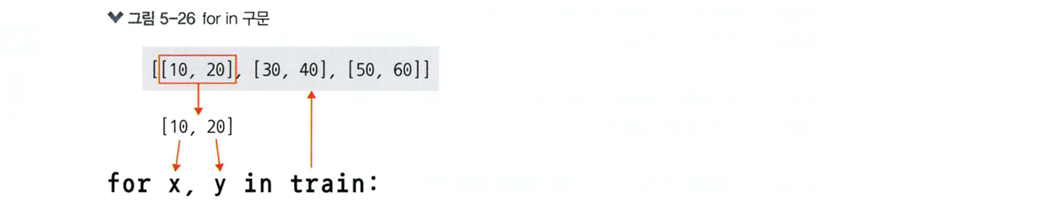

    # (3)
    모델이 데이터를 처리하기 위해서는 모델과 데이터가 동일한 장치(CPU 또는 GPU)에 있어야 함.

    # (4)
    Autograd: 자동 미분을 수행하는 파이토치의 핵심 패키지로, 자동 미분에 대한 값을 저장하기 위해 테이프(tape)를 사용함.
    순전파 단계에서 태이프는 수행하는 모든 연산을 저장하고, 역전파 단계에서 저장된 값들을 꺼내서 사용함.
    따라서 역전파를 위한 자동 미분을 계산하기 위해서는 torch.autograd 패키지 안에 있는 Variable을 이용해야 함.

    # (5)
    - 분류 문제에 대한 정확도: 전체 예측에 대한 정확한 예측의 비율.
        classification accuracy = correct predictions / total predictions

    - 결과에 100을 곱하여 백분율로 표시
        classification accuracy = correct predictions / total predictions * 100

    - 값을 반전시켜 오분류율로 표현
        error rate = (1 - (correct predictions / total predictions)) * 100

**분류 문제에서 클래스가 세 개 이상일 때 주의할 점**
- 정확도가 80% 이상이었다고 해도, 80%라는 값이 모든 클래스가 동등하게 고려된
 것인지, 특정 클래스의 분류가 높았던 것인지에 대해 알 수 없음
- 정확도가 90% 이상이었다고 해도, 100개의 데이터 중 90개가 하나의 클래스에
속할 경우 90%의 정확도는 높다고 할 수 없음. 즉, 모든 데이터를 특정 클래스에 속한다고 예측해도 90%의 예측 결과가 나오기 때문에 데이터 특성에 따라 정확도를 잘 관측해야 함

---

## 합성곱 신경망 생성

In [22]:
# 합성곱 네트워크 생성

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(    # (1)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),   # (2)
            nn.BatchNorm2d(32),   # (3)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # (4)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)   # (5)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)   # 마지막 계층의 out_features는 클래스 개수를 의미

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

    # (1)
    nn.Sequential: 계층을 차례로 쌓을 수 있도록 Wx+b와 같은 수식과 활성화 함수를 연결해 주는 역할.
    여러 개의 계층을 하나의 컨테이너에 구현하는 방법

    # (2)
    합성곱층: 합성곱 연산을 통해서 이미지의 특징을 추출함.
    커널이라는 n X m 크기의 행렬이 높이 X 너비 크기의 이미지를 처음부터 끝까지 훑으면서 각 원소 값끼리 곱한 후 모두 더한 값을 출력함. 커널은 일반적으로 3X3이나 5X5를 사용함.

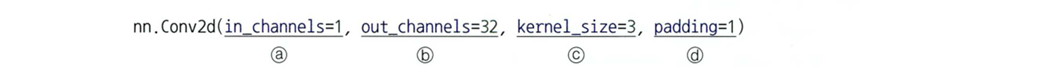

    ## (a)
    in_channels: 입력 채널(깊이)의 수. 흑백 이미지는 1, RGB 값을 가진 이미지는 3

    ## (b)
    out_channels: 출력 채널의 수.

    ## (c)
    kernel_size: 커널 크기
    kernel_size=3이라고 했을 때, 커널의 크기는 (3, 3)으로 정사각형을 의미하며 직사각형을 사용하고 싶다면 (3, 5)처럼 지정.

    ## (d)
    padding: 패딩 크기를 의미하는 것으로 출력 크기를 조정하기 위해 입력 데이터 주위에 0을 채움. 패딩 값이 클수록 출력 크기도 커짐

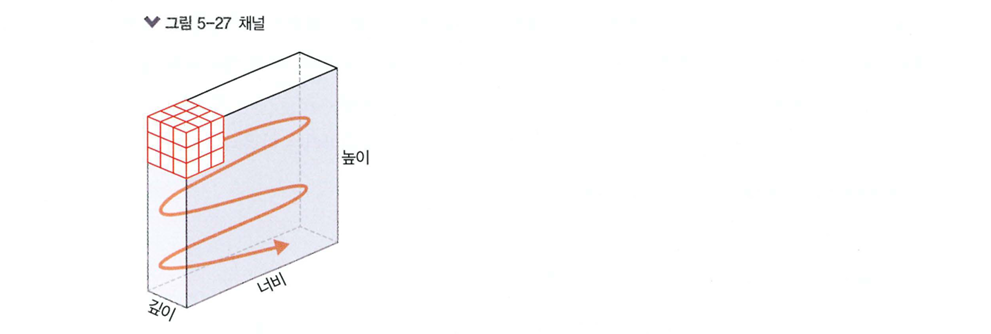

    # (3)
    BatchNorm2d: 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화하는 것 -> 분포를 가우시안 형태로 만듦

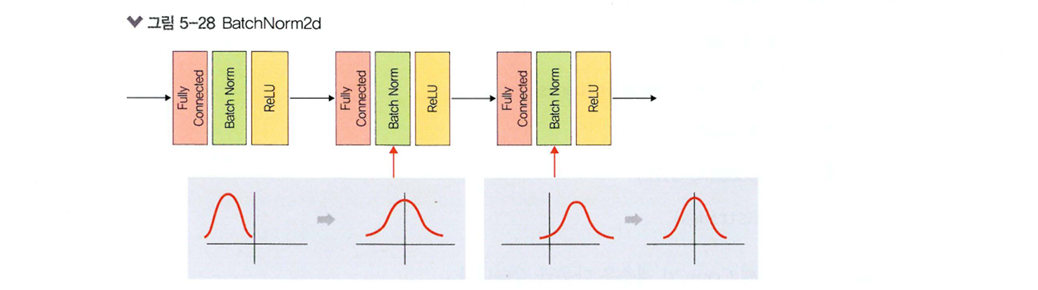

->  평균은 0, 표준편차는 1로 데이터의 분포가 조정됨

    # (4)
    MaxPoo12d: 이미지 크기를 축소시키는 용도로 사용.
    풀링 계층은 합성곱층의 출력 데이터를 입력으로 받아서 출력 데이터의 크기를 줄이거나 특정 데이터를 강조.
    - 풀링 계층을 처리하는 방법
        - 최대 풀링(max pooling)
        - 평균 풀링(averagc pooling)
        - 최소 풀링(min pooling)

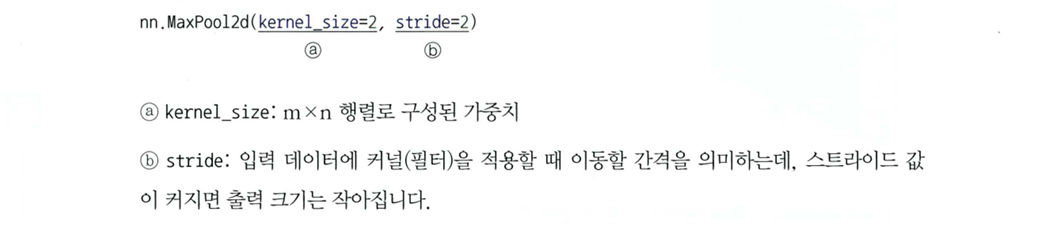

    # (5)
    클래스를 분류하기 위해서는 이미지 형태의 데이터를 배열 형태로 변환하여 작업해야 함. 패딩과 스트라이드의 값에 따라 출력 크기가 달라지며, 줄어든 출력 크기는 최종적으로 분류를 담당하는 완전연결층(fully connected layer)으로 전달됨.

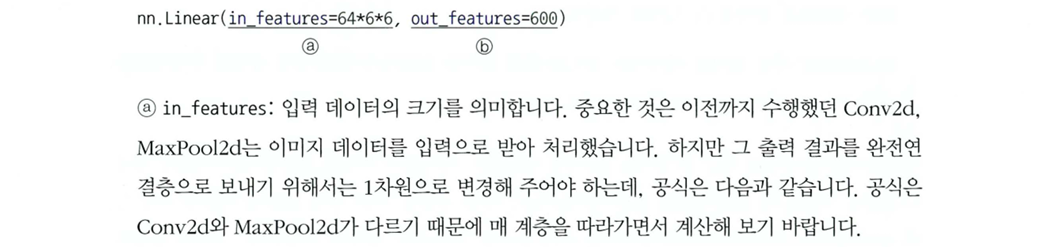

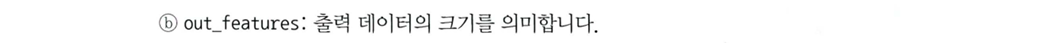

---

> **Conv2d 계층에서의 출력 크기 구하는 공식**

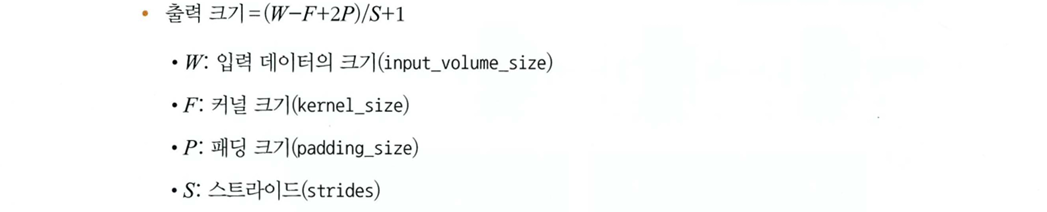

Ex) 첫 번째 Conv2d 계층

```python
nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
```

출력 크기: (28-3+2*1)/(1+1) = 28

* Fashion_mnist의 입력 크기는 (28 x 28)로, 가로와 세로가 모두 동일하므로 28을 사용하며, stride가 명시되어 있지 않다면 stride 기본값은 (1, 1).
* 계산 결과를 적용하면 출력의 형태는 [32, 28, 28]가 됨.

---

> **MaxPool2d 계층에서의 출력 크기 구하는 공식**

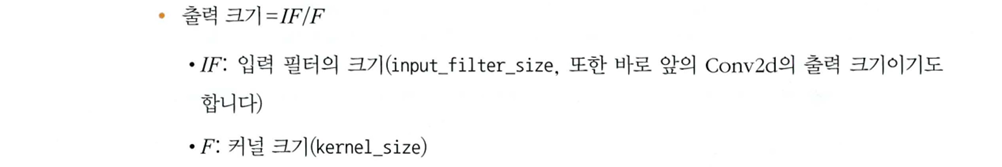

Ex) 첫 번째 MaxPool2d 계층

```python
nn.MaxPool2d(kernel_size=2, stride=2)
```

출력 크기: 784 / 2 = 392

* 784는 첫 번째 Conv2d에서 계산한 결과
* 계산 결과를 적용하면 출력의 형태는 [32. 392. 392]가 됨. 그리고 가장 앞의 32는 바로 앞 Conv2d 계층의 out_channels.

---

    # (6)
    합성곱층에서 완전연결층으로 변경되기 때문에 데이터의 형태를 1차원으로 바꾸어 줌. 이때 out.size(0)은 결국 100을 의미. 따라서 (100, ?) 크기의 텐서로 변경하겠다는 의미.
    
    out.view(out.size(0), -1)에서 ‘-1’은 행의 수는 정확히 알고 있지만 열의 수를 알지 못할 때 사용함.

---

##  합성곱 네트워크를 사용하기 위한 파라미터를 정의

In [23]:
# 합성곱 네트워크를 위한 파라미터 정의

learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


-> 합성곱 네트워크의 구조 출력

In [24]:
# 모델 학습 및 성능 평가

num_epochs = 5
count = 0
loss_list = []    # (1)
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:   # (2)
        images, labels = images.to(device), labels.to(device)   # (3)

        train = Variable(images.view(100, 1, 28, 28))   # (4)
        labels = Variable(labels)

        outputs = model(train)   # 학습 데이터를 모델에 적용
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):    # count를 50으로 나누었을 때 나머지가 0이 아니라면 실행
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)

                test = Variable(images.view(100, 1, 28, 28))

                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()

                total += len(labels)

            accuracy = correct * 100 / total   # (5)
            loss_list.append(loss.data)        # (1')
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Iteration: 500, Loss: 0.44254955649375916, Accuracy: 87.98999786376953%
Iteration: 1000, Loss: 0.37787970900535583, Accuracy: 87.66000366210938%
Iteration: 1500, Loss: 0.2839837372303009, Accuracy: 89.26000213623047%
Iteration: 2000, Loss: 0.20543703436851501, Accuracy: 89.05000305175781%
Iteration: 2500, Loss: 0.12609046697616577, Accuracy: 89.97000122070312%
Iteration: 3000, Loss: 0.2019049972295761, Accuracy: 90.44000244140625%


-> 심층 신경망과 비교하여 정확도가 약간 높음.